In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda



# Zadanie: Implementacja Generative Adversial Networks

<!-- <div class="small-font"> -->

Na podstawie dostraczonego wysokopoziomowego opisu architektury GAN proszę przpeorawdzić implementację modułów:
1) Generatora (dekodera opeartego o VAE, rozmiar wektora latentnego: `16`).
2) Dyskryminatora (klasyfikator całego obrazu)
Następnie proszę je spiąć razem i podjąć próby wytrenowania ich od zera na zbiorze Fashion-MNIST. 

Po treningu, proszę przygotować prosty skrypt umożliwający na ręczne nastawianie wektora latentnego (w celu eksploracji przestrzeni ukrytej).

<!-- </div> -->


### Generator

Generator to jest część GAN'a odpowiedzialna za generowanie obrazu. Dostaje on losowy wektor (punkt w przestrzeni latentnej) i ma zwrócić z tego jakiś tam obraz. Następnie jest on oceniany w ten sposób, że ekspert ocenia czcy jest on prawdziwy czy fałszywy.


loss_G = -log(D(fake))

gdize D(fake) - prawdopodobienstwo że dyksriminator uznał to za prawdziwe

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=16):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 7 * 7 * 128),
            nn.BatchNorm1d(7 * 7 * 128),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            # Input: 128 x 7 x 7
            nn.ConvTranspose2d(
                128, 64, kernel_size=4, stride=2, padding=1
            ),  # -> 64 x 14 x 14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(
                64, 32, kernel_size=4, stride=2, padding=1
            ),  # -> 32 x 28 x 28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),  # -> 1 x 28 x 28
            nn.Tanh(),  # Output in range [-1, 1]
        )

    def forward(self, z):
        # z: (batch_size, latent_dim)
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)  # Reshape to (batch_size, 128, 7, 7)
        x = self.decoder(x)
        return x


generator = Generator(latent_dim=16).to(device)
z_test = torch.randn(4, 16).to(device)
fake_imgs = generator(z_test)
print(f"Generator output shape: {fake_imgs.shape}")

Generator output shape: torch.Size([4, 1, 28, 28])


### Dyskryminator

Klasyfikuje czy wygenerowany obraz jest prawdziwy lub fałszywy. Zwykła sieć konwolucyjna - klasyfikator binarny

loss_D = log(D(real)) + log(1-D(fake))

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.encoder = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # -> 32 x 14 x 14
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # -> 64 x 7 x 7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # -> 128 x 4 x 4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),  # Output probability [0, 1]
        )

    def forward(self, x):
        # x: (batch_size, 1, 28, 28)
        features = self.encoder(x)
        output = self.classifier(features)
        return output


discriminator = Discriminator().to(device)
x_test = torch.randn(4, 1, 28, 28).to(device)
output = discriminator(x_test)
print(output)
print(f"Discriminator output shape: {output.shape}")

tensor([[0.5229],
        [0.4820],
        [0.5024],
        [0.5321]], device='cuda:0', grad_fn=<SigmoidBackward0>)
Discriminator output shape: torch.Size([4, 1])


### Przygotowanie danych (Fashion-MNIST)

In [11]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),  # norm to [-1, 1]
    ]
)

train_dataset = datasets.FashionMNIST(
    root=".data", train=True, download=True, transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=".data", train=False, download=True, transform=transform
)

batch_size = 128
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of train batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Train dataset size: 60000
Test dataset size: 10000
Number of train batches: 469
Number of test batches: 79


### Trening GAN

In [12]:
latent_dim = 16
generator = Generator(latent_dim=latent_dim).to(device)
discriminator = Discriminator().to(device)

lr = 0.0002
beta1 = 0.5
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

criterion = nn.BCELoss()

print("Models initialized!")
print(f"Generator parameters: {sum(p.numel() for p in generator.parameters())}")
print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters())}")

Models initialized!
Generator parameters: 1793729
Discriminator parameters: 632417


Epoch 1/50: 100%|██████████| 469/469 [00:17<00:00, 27.28it/s, D_loss=1.3045, G_loss=1.0496, D(real)=0.5416, D(fake)=0.3912]


Epoch 1: Train G=1.2294, D=1.1230 | Eval G=0.9476, D=1.0678


Epoch 2/50: 100%|██████████| 469/469 [00:18<00:00, 25.85it/s, D_loss=1.2845, G_loss=0.7989, D(real)=0.5311, D(fake)=0.4687]


Epoch 2: Train G=0.9058, D=1.2639 | Eval G=0.7711, D=1.1450


Epoch 3/50: 100%|██████████| 469/469 [00:17<00:00, 27.23it/s, D_loss=1.3632, G_loss=0.8194, D(real)=0.4900, D(fake)=0.4537]


Epoch 3: Train G=0.8473, D=1.3011 | Eval G=0.7544, D=1.2314


Epoch 4/50: 100%|██████████| 469/469 [00:18<00:00, 25.97it/s, D_loss=1.3851, G_loss=0.8093, D(real)=0.5076, D(fake)=0.4635]


Epoch 4: Train G=0.8104, D=1.3257 | Eval G=0.7722, D=1.2641


Epoch 5/50: 100%|██████████| 469/469 [00:17<00:00, 27.34it/s, D_loss=1.4023, G_loss=0.7512, D(real)=0.4893, D(fake)=0.4850]


Epoch 5: Train G=0.7866, D=1.3422 | Eval G=0.7068, D=1.2933


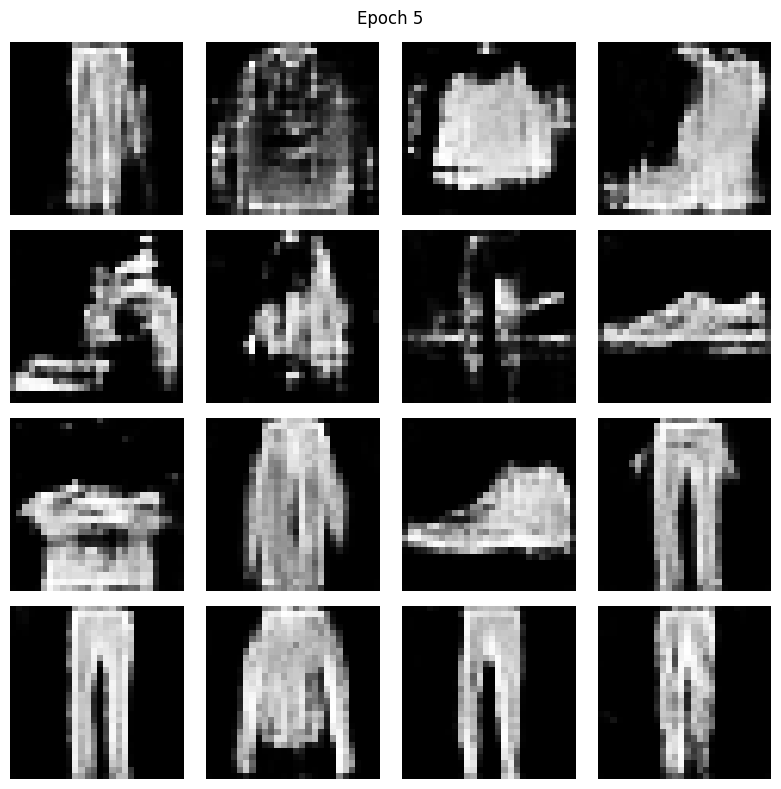

Epoch 6/50: 100%|██████████| 469/469 [00:17<00:00, 26.51it/s, D_loss=1.3354, G_loss=0.7649, D(real)=0.5149, D(fake)=0.4781]


Epoch 6: Train G=0.7744, D=1.3513 | Eval G=0.7246, D=1.3026


Epoch 7/50: 100%|██████████| 469/469 [00:17<00:00, 27.02it/s, D_loss=1.3321, G_loss=0.7447, D(real)=0.5190, D(fake)=0.4825]


Epoch 7: Train G=0.7616, D=1.3561 | Eval G=0.6926, D=1.3087


Epoch 8/50: 100%|██████████| 469/469 [00:17<00:00, 27.21it/s, D_loss=1.3827, G_loss=0.7297, D(real)=0.5007, D(fake)=0.4888]


Epoch 8: Train G=0.7591, D=1.3559 | Eval G=0.6907, D=1.3108


Epoch 9/50: 100%|██████████| 469/469 [00:18<00:00, 25.52it/s, D_loss=1.3839, G_loss=0.8371, D(real)=0.4901, D(fake)=0.4422]


Epoch 9: Train G=0.7537, D=1.3607 | Eval G=0.7164, D=1.3276


Epoch 10/50: 100%|██████████| 469/469 [00:17<00:00, 27.12it/s, D_loss=1.3728, G_loss=0.7232, D(real)=0.5170, D(fake)=0.4939]


Epoch 10: Train G=0.7507, D=1.3619 | Eval G=0.6961, D=1.3235


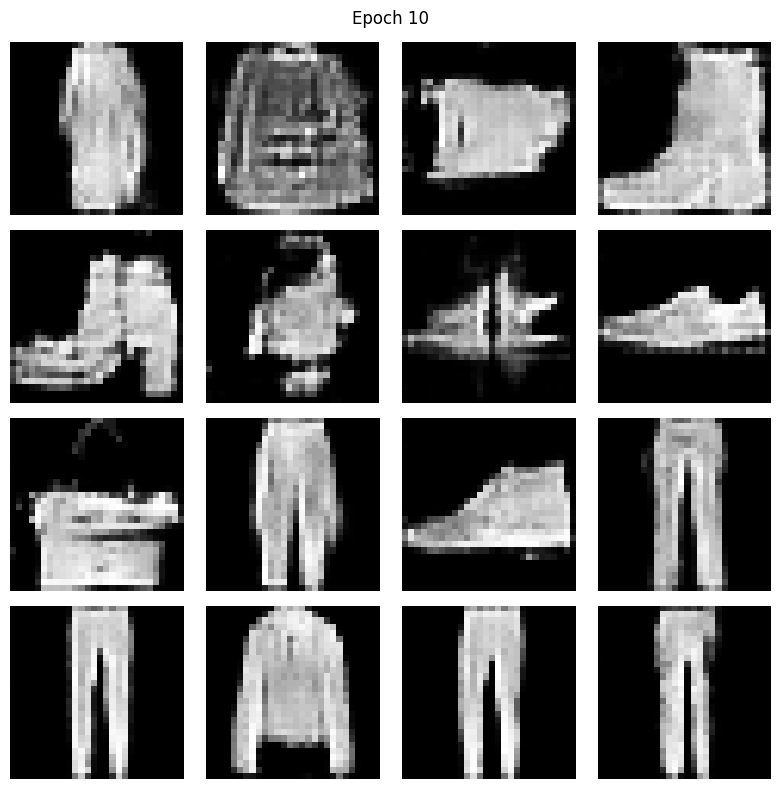

Epoch 11/50: 100%|██████████| 469/469 [00:18<00:00, 25.94it/s, D_loss=1.4070, G_loss=0.7362, D(real)=0.4865, D(fake)=0.4836]


Epoch 11: Train G=0.7483, D=1.3635 | Eval G=0.6929, D=1.3295


Epoch 12/50: 100%|██████████| 469/469 [00:17<00:00, 27.50it/s, D_loss=1.3831, G_loss=0.7492, D(real)=0.5022, D(fake)=0.4779]


Epoch 12: Train G=0.7462, D=1.3633 | Eval G=0.6848, D=1.3277


Epoch 13/50: 100%|██████████| 469/469 [00:17<00:00, 26.50it/s, D_loss=1.3227, G_loss=0.7605, D(real)=0.5270, D(fake)=0.4728]


Epoch 13: Train G=0.7453, D=1.3636 | Eval G=0.6883, D=1.3269


Epoch 14/50: 100%|██████████| 469/469 [00:17<00:00, 27.36it/s, D_loss=1.3563, G_loss=0.7526, D(real)=0.5121, D(fake)=0.4778]


Epoch 14: Train G=0.7464, D=1.3625 | Eval G=0.6809, D=1.3305


Epoch 15/50: 100%|██████████| 469/469 [00:17<00:00, 27.26it/s, D_loss=1.3546, G_loss=0.7182, D(real)=0.5222, D(fake)=0.4923]


Epoch 15: Train G=0.7427, D=1.3634 | Eval G=0.6462, D=1.3369


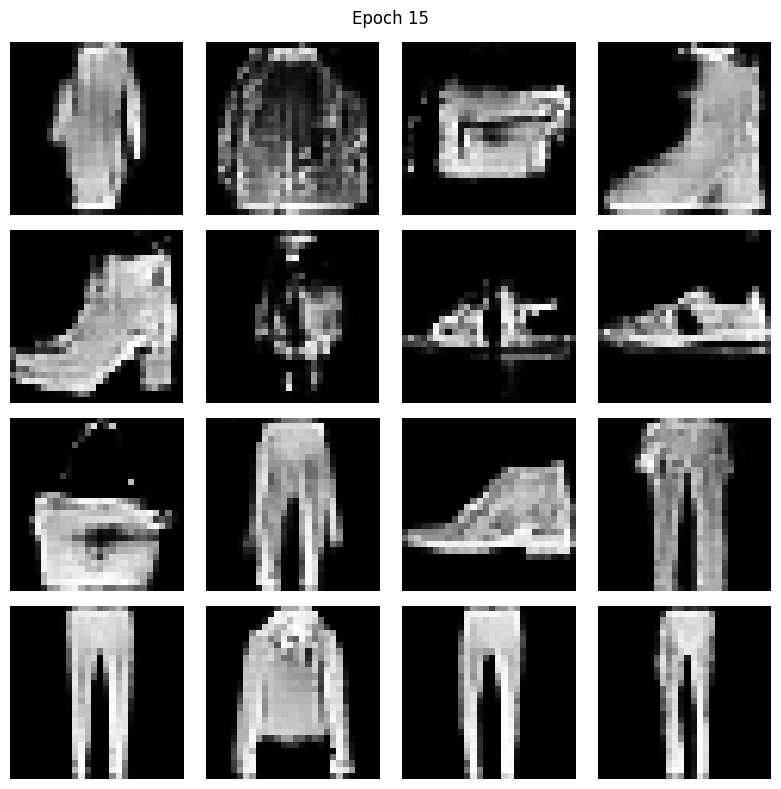

Epoch 16/50: 100%|██████████| 469/469 [00:17<00:00, 26.82it/s, D_loss=1.3780, G_loss=0.7093, D(real)=0.4976, D(fake)=0.4963]


Epoch 16: Train G=0.7403, D=1.3660 | Eval G=0.6586, D=1.3470


Epoch 17/50: 100%|██████████| 469/469 [00:16<00:00, 28.26it/s, D_loss=1.3936, G_loss=0.7293, D(real)=0.5067, D(fake)=0.4867]


Epoch 17: Train G=0.7383, D=1.3673 | Eval G=0.6709, D=1.3435


Epoch 18/50: 100%|██████████| 469/469 [00:17<00:00, 27.58it/s, D_loss=1.3460, G_loss=0.7394, D(real)=0.5156, D(fake)=0.4824]


Epoch 18: Train G=0.7350, D=1.3683 | Eval G=0.6675, D=1.3383


Epoch 19/50: 100%|██████████| 469/469 [00:16<00:00, 28.37it/s, D_loss=1.3859, G_loss=0.7287, D(real)=0.5172, D(fake)=0.4871]


Epoch 19: Train G=0.7314, D=1.3693 | Eval G=0.6727, D=1.3407


Epoch 20/50: 100%|██████████| 469/469 [00:17<00:00, 27.30it/s, D_loss=1.3786, G_loss=0.7442, D(real)=0.5057, D(fake)=0.4794]


Epoch 20: Train G=0.7342, D=1.3674 | Eval G=0.6785, D=1.3291


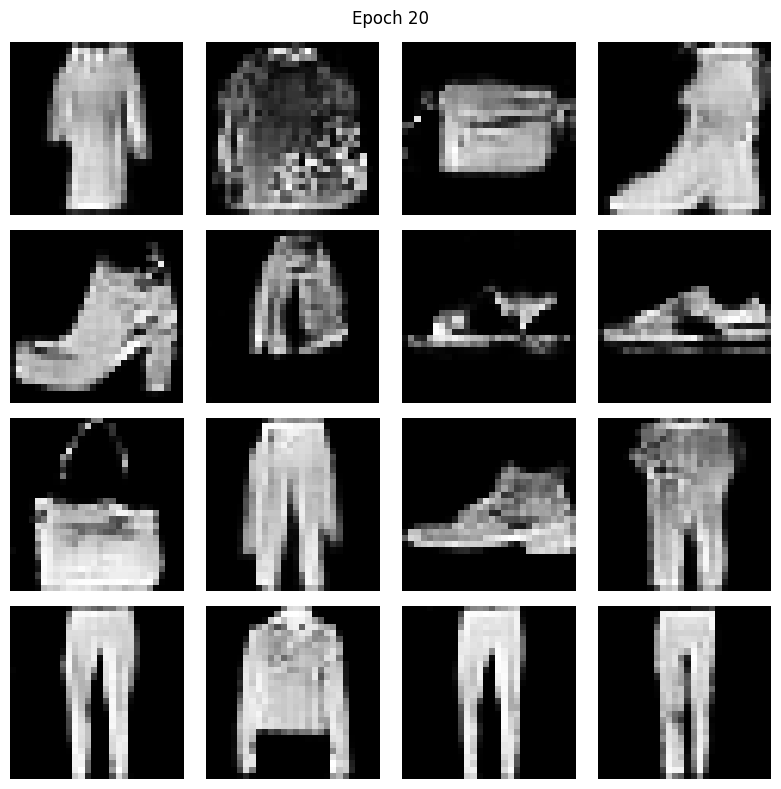

Epoch 21/50: 100%|██████████| 469/469 [00:16<00:00, 28.63it/s, D_loss=1.4071, G_loss=0.7406, D(real)=0.4929, D(fake)=0.4817]


Epoch 21: Train G=0.7335, D=1.3689 | Eval G=0.6944, D=1.3378


Epoch 22/50: 100%|██████████| 469/469 [00:17<00:00, 27.11it/s, D_loss=1.3640, G_loss=0.7318, D(real)=0.5155, D(fake)=0.4857]


Epoch 22: Train G=0.7333, D=1.3674 | Eval G=0.6688, D=1.3388


Epoch 23/50: 100%|██████████| 469/469 [00:16<00:00, 28.12it/s, D_loss=1.3690, G_loss=0.7530, D(real)=0.5056, D(fake)=0.4757]


Epoch 23: Train G=0.7350, D=1.3671 | Eval G=0.6647, D=1.3319


Epoch 24/50: 100%|██████████| 469/469 [00:17<00:00, 27.47it/s, D_loss=1.3784, G_loss=0.7400, D(real)=0.5076, D(fake)=0.4816]


Epoch 24: Train G=0.7339, D=1.3664 | Eval G=0.6728, D=1.3362


Epoch 25/50: 100%|██████████| 469/469 [00:16<00:00, 28.36it/s, D_loss=1.3369, G_loss=0.7210, D(real)=0.5321, D(fake)=0.4917]


Epoch 25: Train G=0.7342, D=1.3674 | Eval G=0.6729, D=1.3476


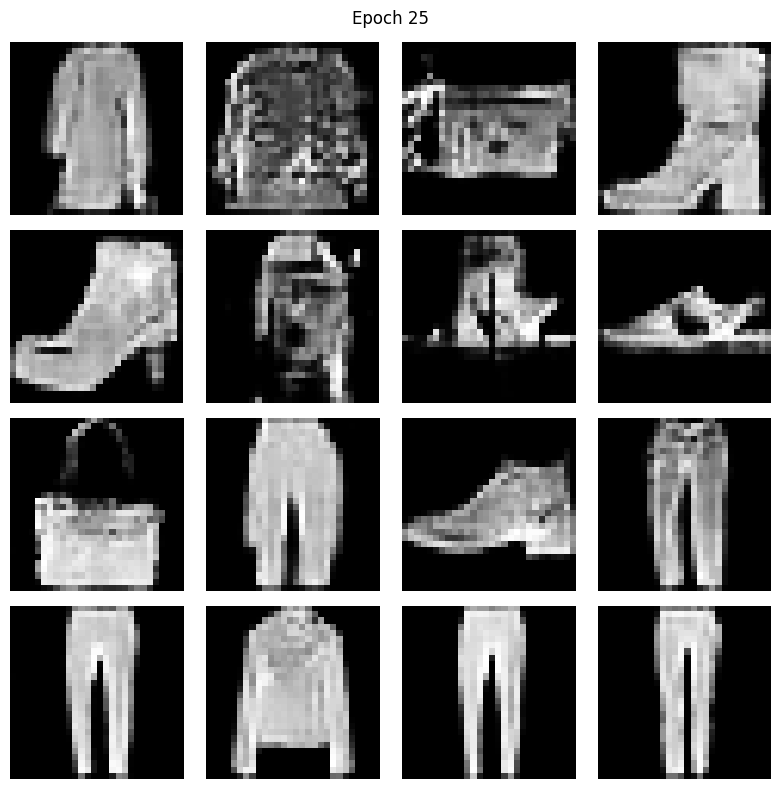

Epoch 26/50: 100%|██████████| 469/469 [00:17<00:00, 27.29it/s, D_loss=1.3603, G_loss=0.7428, D(real)=0.5222, D(fake)=0.4811]


Epoch 26: Train G=0.7345, D=1.3666 | Eval G=0.6820, D=1.3378


Epoch 27/50: 100%|██████████| 469/469 [00:16<00:00, 28.90it/s, D_loss=1.3121, G_loss=0.7161, D(real)=0.5310, D(fake)=0.4928]


Epoch 27: Train G=0.7314, D=1.3684 | Eval G=0.6771, D=1.3421


Epoch 28/50: 100%|██████████| 469/469 [00:16<00:00, 27.73it/s, D_loss=1.3265, G_loss=0.7243, D(real)=0.5072, D(fake)=0.4902]


Epoch 28: Train G=0.7342, D=1.3669 | Eval G=0.6827, D=1.3450


Epoch 29/50: 100%|██████████| 469/469 [00:16<00:00, 29.11it/s, D_loss=1.3630, G_loss=0.7086, D(real)=0.5119, D(fake)=0.4965]


Epoch 29: Train G=0.7344, D=1.3673 | Eval G=0.6781, D=1.3429


Epoch 30/50: 100%|██████████| 469/469 [00:16<00:00, 27.61it/s, D_loss=1.3506, G_loss=0.7334, D(real)=0.5155, D(fake)=0.4836]


Epoch 30: Train G=0.7329, D=1.3680 | Eval G=0.6669, D=1.3368


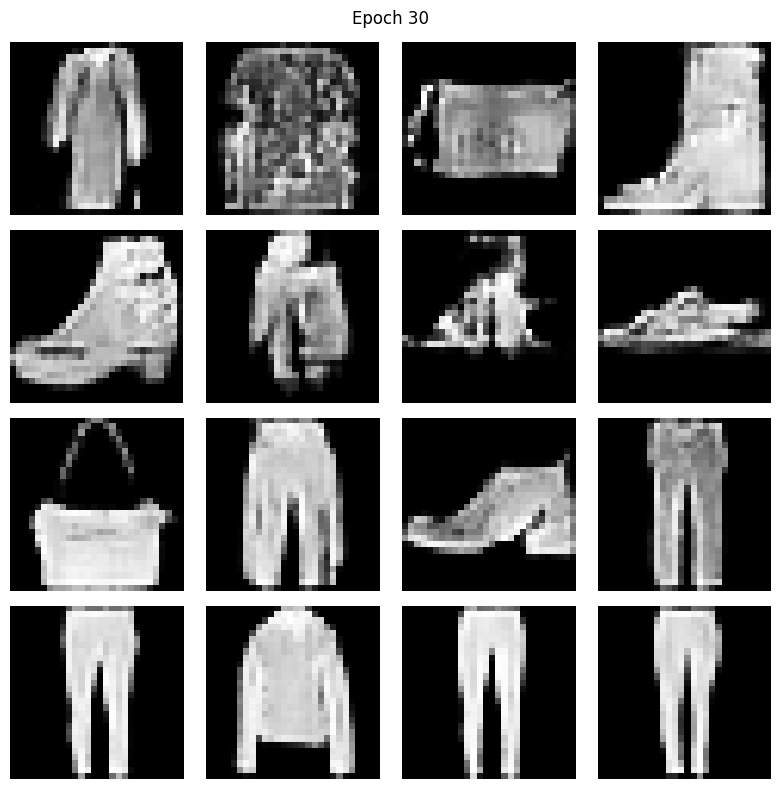

Epoch 31/50: 100%|██████████| 469/469 [00:16<00:00, 28.63it/s, D_loss=1.3369, G_loss=0.7391, D(real)=0.5202, D(fake)=0.4822]


Epoch 31: Train G=0.7322, D=1.3676 | Eval G=0.6682, D=1.3463


Epoch 32/50: 100%|██████████| 469/469 [00:16<00:00, 27.72it/s, D_loss=1.3427, G_loss=0.7705, D(real)=0.5073, D(fake)=0.4675]


Epoch 32: Train G=0.7317, D=1.3695 | Eval G=0.6664, D=1.3525


Epoch 33/50: 100%|██████████| 469/469 [00:16<00:00, 28.36it/s, D_loss=1.3304, G_loss=0.7148, D(real)=0.5291, D(fake)=0.4939]


Epoch 33: Train G=0.7312, D=1.3681 | Eval G=0.6569, D=1.3393


Epoch 34/50: 100%|██████████| 469/469 [00:17<00:00, 27.57it/s, D_loss=1.3872, G_loss=0.7764, D(real)=0.4965, D(fake)=0.4643]


Epoch 34: Train G=0.7305, D=1.3691 | Eval G=0.7055, D=1.3420


Epoch 35/50: 100%|██████████| 469/469 [00:16<00:00, 28.56it/s, D_loss=1.3274, G_loss=0.7420, D(real)=0.5188, D(fake)=0.4813]


Epoch 35: Train G=0.7328, D=1.3665 | Eval G=0.6696, D=1.3516


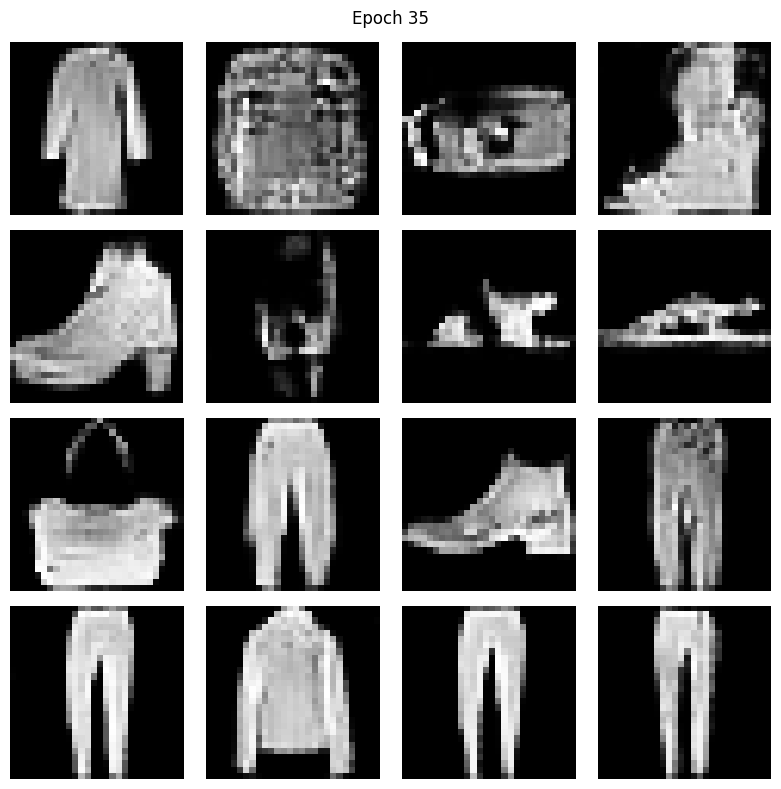

Epoch 36/50: 100%|██████████| 469/469 [00:17<00:00, 27.50it/s, D_loss=1.3790, G_loss=0.7333, D(real)=0.5029, D(fake)=0.4855]


Epoch 36: Train G=0.7311, D=1.3676 | Eval G=0.6751, D=1.3435


Epoch 37/50: 100%|██████████| 469/469 [00:16<00:00, 28.34it/s, D_loss=1.3816, G_loss=0.7356, D(real)=0.4992, D(fake)=0.4849]


Epoch 37: Train G=0.7314, D=1.3675 | Eval G=0.6741, D=1.3440


Epoch 38/50: 100%|██████████| 469/469 [00:17<00:00, 27.31it/s, D_loss=1.3250, G_loss=0.7331, D(real)=0.5169, D(fake)=0.4853]


Epoch 38: Train G=0.7334, D=1.3681 | Eval G=0.6709, D=1.3410


Epoch 39/50: 100%|██████████| 469/469 [00:16<00:00, 27.63it/s, D_loss=1.3389, G_loss=0.7576, D(real)=0.5037, D(fake)=0.4733]


Epoch 39: Train G=0.7305, D=1.3675 | Eval G=0.6738, D=1.3374


Epoch 40/50: 100%|██████████| 469/469 [00:17<00:00, 27.07it/s, D_loss=1.3654, G_loss=0.7331, D(real)=0.5108, D(fake)=0.4834]


Epoch 40: Train G=0.7323, D=1.3679 | Eval G=0.6819, D=1.3426


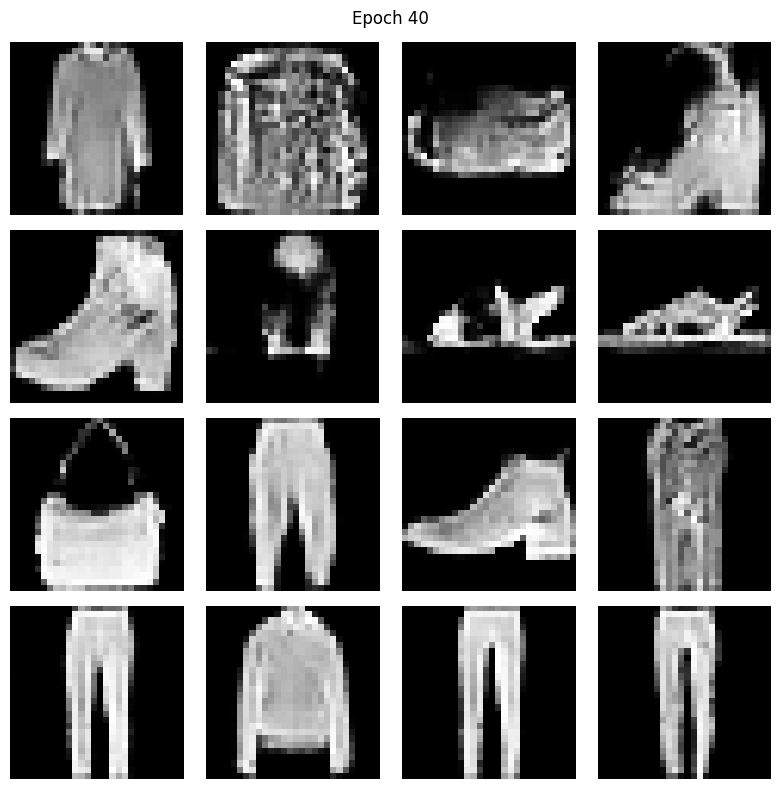

Epoch 41/50: 100%|██████████| 469/469 [00:16<00:00, 28.64it/s, D_loss=1.3601, G_loss=0.7704, D(real)=0.4991, D(fake)=0.4691]


Epoch 41: Train G=0.7320, D=1.3662 | Eval G=0.6750, D=1.3471


Epoch 42/50: 100%|██████████| 469/469 [00:17<00:00, 27.45it/s, D_loss=1.3557, G_loss=0.7472, D(real)=0.5158, D(fake)=0.4787]


Epoch 42: Train G=0.7335, D=1.3669 | Eval G=0.6756, D=1.3485


Epoch 43/50: 100%|██████████| 469/469 [00:16<00:00, 28.48it/s, D_loss=1.3587, G_loss=0.7426, D(real)=0.5156, D(fake)=0.4793]


Epoch 43: Train G=0.7309, D=1.3683 | Eval G=0.6697, D=1.3380


Epoch 44/50: 100%|██████████| 469/469 [00:17<00:00, 27.21it/s, D_loss=1.3342, G_loss=0.7280, D(real)=0.5239, D(fake)=0.4890]


Epoch 44: Train G=0.7312, D=1.3676 | Eval G=0.6631, D=1.3467


Epoch 45/50: 100%|██████████| 469/469 [00:16<00:00, 28.77it/s, D_loss=1.3643, G_loss=0.7548, D(real)=0.5068, D(fake)=0.4751]


Epoch 45: Train G=0.7323, D=1.3682 | Eval G=0.6786, D=1.3415


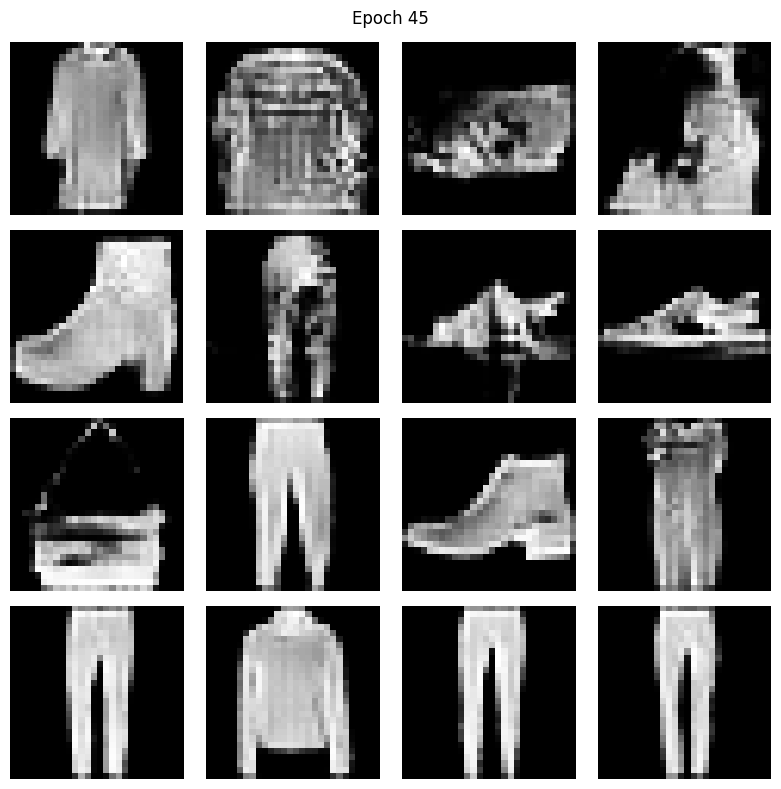

Epoch 46/50: 100%|██████████| 469/469 [00:17<00:00, 27.05it/s, D_loss=1.3587, G_loss=0.7342, D(real)=0.5058, D(fake)=0.4847]


Epoch 46: Train G=0.7317, D=1.3665 | Eval G=0.6833, D=1.3482


Epoch 47/50: 100%|██████████| 469/469 [00:16<00:00, 28.27it/s, D_loss=1.3667, G_loss=0.7515, D(real)=0.5031, D(fake)=0.4761]


Epoch 47: Train G=0.7319, D=1.3667 | Eval G=0.6778, D=1.3406


Epoch 48/50: 100%|██████████| 469/469 [00:16<00:00, 27.78it/s, D_loss=1.3485, G_loss=0.7205, D(real)=0.5194, D(fake)=0.4918]


Epoch 48: Train G=0.7329, D=1.3658 | Eval G=0.6894, D=1.3392


Epoch 49/50: 100%|██████████| 469/469 [00:16<00:00, 28.47it/s, D_loss=1.3603, G_loss=0.7414, D(real)=0.5010, D(fake)=0.4812]


Epoch 49: Train G=0.7330, D=1.3668 | Eval G=0.6872, D=1.3379


Epoch 50/50: 100%|██████████| 469/469 [00:16<00:00, 28.33it/s, D_loss=1.3670, G_loss=0.7152, D(real)=0.5125, D(fake)=0.4941]


Epoch 50: Train G=0.7347, D=1.3657 | Eval G=0.6685, D=1.3431


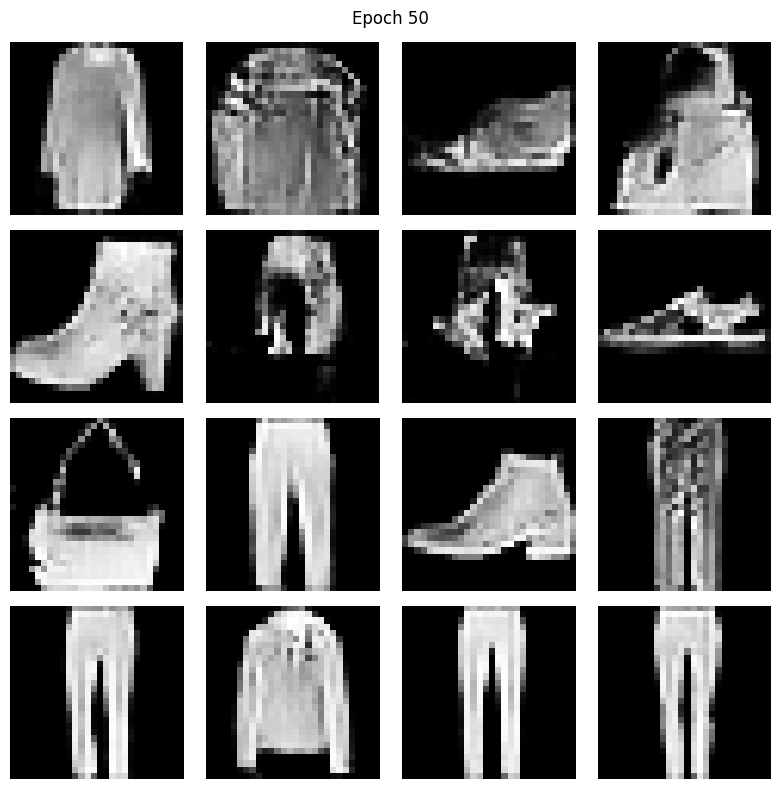

In [13]:
def evaluate_gan():
    """Funkcja do ewaluacji GAN na zbiorze testowym"""
    generator.eval()
    discriminator.eval()

    total_g_loss = 0
    total_d_loss = 0
    num_batches = 0

    with torch.no_grad():
        for real_imgs, _ in test_loader:
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Ewaluacja dyskryminatora
            real_output = discriminator(real_imgs)
            d_loss_real = criterion(real_output, real_labels)

            z = torch.randn(batch_size, latent_dim).to(device)
            fake_imgs = generator(z)

            fake_output = discriminator(fake_imgs)
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake

            # Ewaluacja generatora
            g_loss = criterion(fake_output, real_labels)

            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
            num_batches += 1

    avg_g_loss = total_g_loss / num_batches
    avg_d_loss = total_d_loss / num_batches

    return avg_g_loss, avg_d_loss


def train_gan(num_epochs=50):
    generator.train()
    discriminator.train()

    train_g_losses = []
    train_d_losses = []
    eval_g_losses = []
    eval_d_losses = []

    fixed_noise = torch.randn(16, latent_dim).to(device)

    for epoch in range(num_epochs):
        epoch_g_loss = 0
        epoch_d_loss = 0

        # Trening
        generator.train()
        discriminator.train()

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")
        for i, (real_imgs, _) in enumerate(pbar):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            optimizer_D.zero_grad()

            # real img loss
            real_output = discriminator(real_imgs)
            d_loss_real = criterion(real_output, real_labels)

            # generating fake images
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_imgs = generator(z)

            # fake img loss
            fake_output = discriminator(fake_imgs.detach())
            d_loss_fake = criterion(fake_output, fake_labels)

            # summary loss
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()

            fake_output = discriminator(fake_imgs)
            g_loss = criterion(fake_output, real_labels)

            g_loss.backward()
            optimizer_G.step()

            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()

            pbar.set_postfix(
                {
                    "D_loss": f"{d_loss.item():.4f}",
                    "G_loss": f"{g_loss.item():.4f}",
                    "D(real)": f"{real_output.mean().item():.4f}",
                    "D(fake)": f"{fake_output.mean().item():.4f}",
                }
            )

        avg_train_g_loss = epoch_g_loss / len(train_loader)
        avg_train_d_loss = epoch_d_loss / len(train_loader)
        train_g_losses.append(avg_train_g_loss)
        train_d_losses.append(avg_train_d_loss)

        avg_eval_g_loss, avg_eval_d_loss = evaluate_gan()
        eval_g_losses.append(avg_eval_g_loss)
        eval_d_losses.append(avg_eval_d_loss)

        print(
            f"Epoch {epoch + 1}: Train G={avg_train_g_loss:.4f}, D={avg_train_d_loss:.4f} | "
            f"Eval G={avg_eval_g_loss:.4f}, D={avg_eval_d_loss:.4f}"
        )

        if (epoch + 1) % 5 == 0:
            generator.eval()
            with torch.no_grad():
                generated_imgs = generator(fixed_noise)

            fig, axes = plt.subplots(4, 4, figsize=(8, 8))
            for idx, ax in enumerate(axes.flat):
                img = generated_imgs[idx].cpu().squeeze().numpy()
                img = (img + 1) / 2
                ax.imshow(img, cmap="gray")
                ax.axis("off")
            plt.suptitle(f"Epoch {epoch + 1}")
            plt.tight_layout()
            plt.show()

    return train_g_losses, train_d_losses, eval_g_losses, eval_d_losses


train_g_losses, train_d_losses, eval_g_losses, eval_d_losses = train_gan(num_epochs=50)

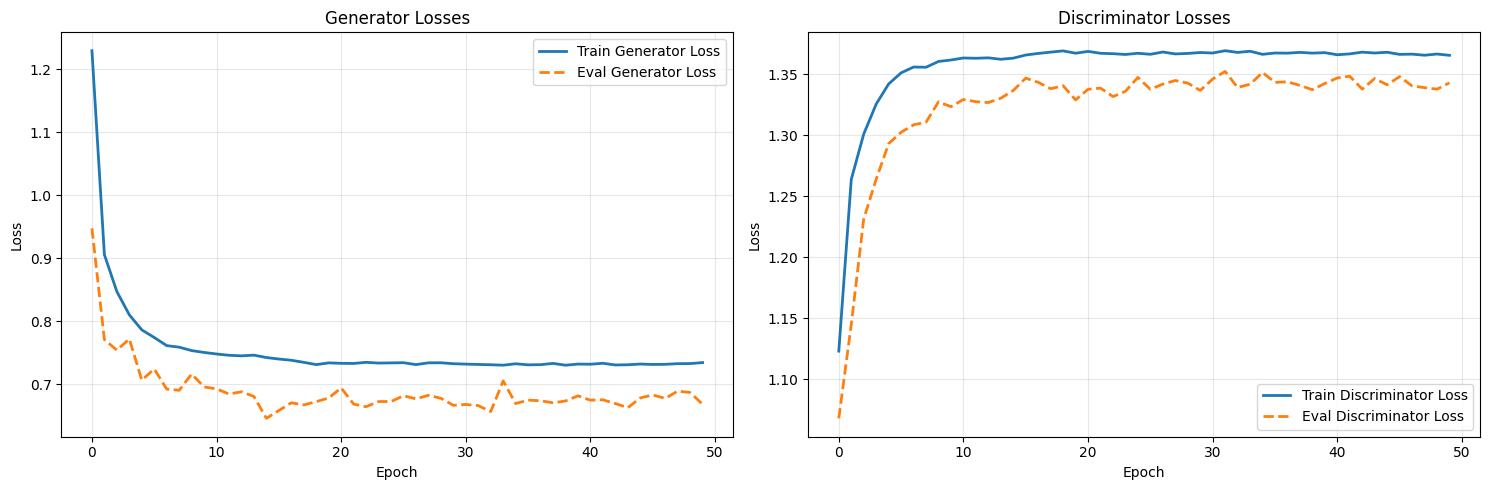

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Generator Loss
ax1.plot(train_g_losses, label="Train Generator Loss", linewidth=2)
ax1.plot(eval_g_losses, label="Eval Generator Loss", linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Generator Losses")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Discriminator Loss
ax2.plot(train_d_losses, label="Train Discriminator Loss", linewidth=2)
ax2.plot(eval_d_losses, label="Eval Discriminator Loss", linewidth=2, linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Discriminator Losses")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Eksploracja przestrzeni latentnej


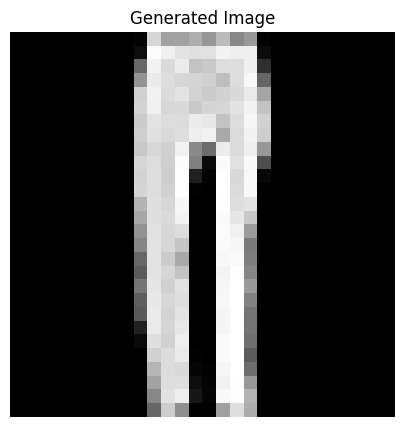

In [20]:
def explore_latent_space(
    latent_vector=None, generator=generator, latent_dim=latent_dim
):
    generator.eval()

    if latent_vector is None:
        latent_vector = torch.randn(1, latent_dim)

    if len(latent_vector.shape) == 1:
        latent_vector = latent_vector.unsqueeze(0)

    latent_vector = latent_vector.to(device)

    with torch.no_grad():
        generated_img = generator(latent_vector)

    img = generated_img[0].cpu().squeeze().numpy()
    img = (img + 1) / 2

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Generated Image")
    plt.show()

    return latent_vector


z = explore_latent_space()

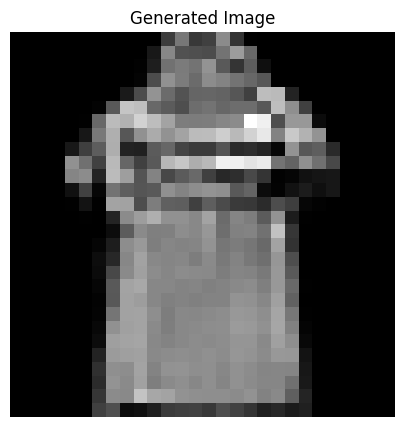

tensor([[ 0.5000, -0.3000,  1.2000,  0.0000, -1.5000,  0.8000, -0.7000,  0.4000,
          0.2000, -0.9000,  1.1000, -0.4000,  0.6000, -0.2000,  0.9000, -1.0000]],
       device='cuda:0')

In [17]:
custom_z = torch.tensor(
    [
        [
            0.5,
            -0.3,
            1.2,
            0.0,
            -1.5,
            0.8,
            -0.7,
            0.4,
            0.2,
            -0.9,
            1.1,
            -0.4,
            0.6,
            -0.2,
            0.9,
            -1.0,
        ]
    ]
)

explore_latent_space(custom_z)

### Zapis i odczyt modelu

In [18]:
torch.save(
    {
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    },
    "gan_fashion_mnist.pth",
)

print("Modele zapisane!")

Modele zapisane!


In [21]:
checkpoint = torch.load("gan_fashion_mnist.pth")
generator.load_state_dict(checkpoint["generator"])
discriminator.load_state_dict(checkpoint["discriminator"])
optimizer_G.load_state_dict(checkpoint["optimizer_G"])
optimizer_D.load_state_dict(checkpoint["optimizer_D"])

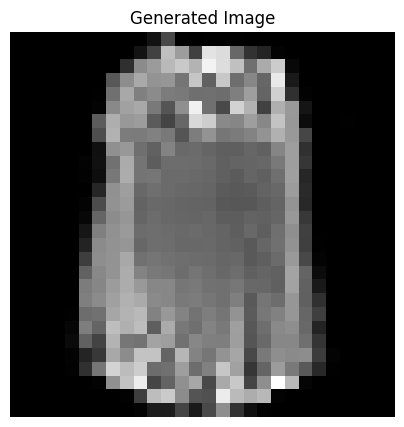

tensor([[ 0.2130,  0.6037,  0.8491, -0.2693,  0.6892, -0.2528, -0.4274,  0.0023,
          0.0046,  1.0281,  0.2030, -1.2909, -1.3294,  0.0836, -0.3793,  0.0097]],
       device='cuda:0')

In [24]:
explore_latent_space(generator=generator, latent_dim=16)